# Walkthrough


In [13]:
from IPython.display import Markdown, display
import pandas as pd

## 1. Creating an Environment

#### Available Environments

In [14]:
import imprl.envs

env_registry = imprl.envs.ENV_REGISTRY
available_envs = list(env_registry)
print("Available environments:", available_envs)

table_lines = [
    "| env_name | available settings |",
    "|---|---|",
]
for env_name, metadata in env_registry.items():
    settings_text = ", ".join(metadata["settings"])
    table_lines.append(f"| `{env_name}` | {settings_text} |")
display(Markdown("\n".join(table_lines)))

Available environments: ['k_out_of_n_finite', 'k_out_of_n_infinite', 'matrix_game']


| env_name | available settings |
|---|---|
| `k_out_of_n_finite` | hard-1-of-5, hard-2-of-5, hard-3-of-5, hard-4-of-5, hard-5-of-5 |
| `k_out_of_n_infinite` | hard-1-of-4_infinite, hard-2-of-4_infinite, hard-3-of-4_infinite, hard-4-of-4_infinite, n2_k1_nomob, n2_k2_nomob, n3_k1_nomob, n3_k2_nomob, n3_k3_nomob, n4_k1_nomob_fpf1.5, n4_k2_nomob_fpf1.5, n4_k3_nomob_fpf1.5, n4_k4_nomob_fpf1.5 |
| `matrix_game` | climb_game, penalty_game |

Keyword arguments:
- name: environment name from the registry
- setting: one of the listed settings for that environment
- single_agent: wrap with SingleAgentWrapper instead of MultiAgentWrapper
- **env_kwargs: forwarded to the core environment constructor
    (common examples for structural environments):
    - percept_type="belief" | "state" | "obs"
    - reward_shaping=True / False
    - time_perception=True / False
    - time_limit=20
    - return_discounted_rewards=True / False (set to True for PPO, MAPPO, IPPO)

In [ ]:
# Example environment creation
env_name = "k_out_of_n_infinite"
setting = "hard-1-of-4_infinite"
single_agent = False
env_kwargs = dict(
    percept_type="belief",
    reward_shaping=True,
    time_perception=False,
    time_limit=20,
    return_discounted_rewards=False,
)

# Environments are created using imprl.envs.make(...)
env = imprl.envs.make(
    name=env_name,
    setting=setting,
    single_agent=single_agent,
    **env_kwargs,
)

The above code cell lists the environment names currently supported by `imprl.envs.make(...)` and creates one example environment.

The returned `env` exposes the standard Gynasium API (e.g. `env.reset()`, `env.step(...)`, etc.)

In [34]:
# Env. objects using the standard Gymnasium API.
obs, info = env.reset()
print("Initial observation:\n", obs)
print("Info:")
for key, value in info.items():
    print(f"  {key}: {value}")
print("-" * 200)

action = [0, 1, 0, 2]
print(f"Action = {action}")
next_obs, reward, termination, truncation, info = env.step(action)
print("Next observation:\n", next_obs)
print("Reward:", reward)
print("Termination:", termination)
print("Truncation:", truncation)
print("Info:")
for key, value in info.items():
    print(f"  {key}: {value}")

Initial observation:
 [[0.6 0.4 0. ]
 [0.6 0.4 0. ]
 [0.6 0.4 0. ]
 [0.6 0.4 0. ]]
Info:
  system_failure: False
  reward_replacement: 0
  reward_inspection: 0
  reward_system: 0
  reward_mobilisation: 0
  state: [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]
  observation: [0 0 1 1]
  inspection_outcomes: [-1 -1 -1 -1]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Action = [0, 1, 0, 2]
Next observation:
 [[0.492      0.456      0.052     ]
 [0.6912     0.3        0.0088    ]
 [0.474      0.466      0.06      ]
 [0.09090909 0.90909091 0.        ]]
Reward: -38.0
Termination: False
Truncation: False
Info:
  system_failure: False
  reward_replacement: -30.0
  reward_inspection: -4.0
  reward_system: -0.0
  reward_mobilisation: -4
  state: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]
  observation: [1 1 0 1]
  inspection_outcomes: 

- The returned `env` object is a actually wrapper around the core environment.

    - Why? The core environment's outputs may not be directly compatible with the learning algorithm you want to use. Therefore, the wrapper exposes a standardized Gymnasium API for interacting     with the environment,as well as some convenience transforms for processing the raw observations returned by the core environment.

- There are two types of wrappers: `MultiAgentWrapper` and `SingleAgentWrapper`. You can specify which wrapper to use via the `single_agent` argument to `imprl.envs.make(...)`.

- The wrapper also has a reference to the core environment via `env.core`. 

In [30]:
# The wrapper exposes convenience transforms such as:
print(f"Observation: shape {obs.shape}\n {obs}\n")

# 1. `system_percept`: returns the system-level percept (e.g. the belief state for all agents).
system_percept = env.system_percept(obs)
system_percept_shape = env.system_percept(obs).shape
print(f"system_percept: shape{system_percept_shape}\n {system_percept}\n")

# 2. `multiagent_percept`: returns a list of agent-level percepts (e.g. the belief state for each agent).
# also augments each agent-level percept with any global information (e.g. the time step) that is shared across all agents.
multiagent_percept = env.multiagent_percept(obs)
multiagent_percept_shape = env.multiagent_percept(obs).shape
print(f"multiagent_percept: shape{multiagent_percept_shape}\n {multiagent_percept}\n")

# 3. `multiagent_idx_percept`: returns a list of agent-level percepts
#    where each percept is augmented with an identity encoding for the corresponding agent.
multiagent_idx_percept = env.multiagent_idx_percept(obs)
multiagent_idx_percept_shape = env.multiagent_idx_percept(obs).shape
print(
    f"multiagent_idx_percept: shape{multiagent_idx_percept_shape}\n {multiagent_idx_percept}\n"
)

Observation: shape (4, 3)
 [[0.6 0.4 0. ]
 [0.6 0.4 0. ]
 [0.6 0.4 0. ]
 [0.6 0.4 0. ]]

system_percept: shape(12,)
 [0.6 0.4 0.  0.6 0.4 0.  0.6 0.4 0.  0.6 0.4 0. ]

multiagent_percept: shape(4, 3)
 [[0.6 0.4 0. ]
 [0.6 0.4 0. ]
 [0.6 0.4 0. ]
 [0.6 0.4 0. ]]

multiagent_idx_percept: shape(4, 7)
 [[1.  0.  0.  0.  0.6 0.4 0. ]
 [0.  1.  0.  0.  0.6 0.4 0. ]
 [0.  0.  1.  0.  0.6 0.4 0. ]
 [0.  0.  0.  1.  0.6 0.4 0. ]]



In practice, you will usually work with:

- `env`: the wrapped environment returned by `imprl.envs.make(...)`
- `env.core`: the underlying core environment
- `env.core.baselines`: baseline values/policies for the chosen setting

In [29]:
# Built-in baselines for the current environment setting.
print(env.core.baselines)

# Inspect the wrapper stack.
print("wrapped env type:", type(env).__name__)
print("core env type:   ", type(env.core).__name__)
print("has core:", hasattr(env, "core"))

{'DoNothing': {'mean': 222.23}, 'FailureReplace': {'mean': 340.65}, 'InspectRepair': {'mean': 70.1877, '95_ci': [70.1216, 70.2537], 'policy_id': 16, 'policy_params': {'inspection_interval': 3, 'num_inspection_components': 1, 'replacement_threshold': 1}}, 'SARSOP': {'mean': 50.41, '95_ci': [50.31, 50.51], 'LBound': 43.6696, 'UBound': 51.8249, 'run_id': 'l9bfLjPX'}}
wrapped env type: MultiAgentWrapper
core env type:    KOutOfN
has core: True


## 2. Evaluate Heuristic Baselines

Use the baseline classes directly when you want explicit control over the heuristic policy and rollout path.


In [35]:
from imprl.baselines.failure_replace import FailureReplace
from imprl.baselines.inspection_repair import InspectionRepairHeuristic

from imprl.runners.parallel import parallel_agent_rollout, parallel_generic_rollout

num_episodes = 100

# FailureReplace behaves like an agent, so use parallel_agent_rollout.
failure_replace = FailureReplace(env)
failure_replace_costs = parallel_agent_rollout(env, failure_replace, num_episodes)
print(f"FailureReplace mean cost: {(failure_replace_costs.mean()):.2f}")

# InspectRepair uses a policy object plus a custom rollout function.
inspect_repair = InspectionRepairHeuristic(env)
policy_id = env.core.baselines["InspectRepair"]["policy_id"]
inspect_repair_policy = inspect_repair.policy_space[policy_id]
inspect_repair_costs = parallel_generic_rollout(
    env,
    inspect_repair_policy,
    inspect_repair.rollout,
    num_episodes,
)

print(f"InspectRepair mean cost:  {(-inspect_repair_costs.mean()):.2f}")

FailureReplace mean cost: 222.24
Number of inspection intervals: 19
Number of inspection components: 4
Number of replacement thresholds: 2
Total number of parameter combinations: 19 x 4 x 2 = 152
InspectRepair mean cost:  69.71


## 3. Train A DRL Agent

Available algorithms:

| Algorithm   | policy regime   | Formulation   | Paradigm   | algorithm type   | parameter sharing   | entry point              |
|:------------|:----------------|:--------------|:-----------|:-----------------|:--------------------|:-------------------------|
| DDQN        | off-policy      | POMDP         | CTCE       | value-based      | True                | train_and_log.py         |
| JAC         | off-policy      | POMDP         | CTCE       | actor-critic     | True                | train_and_log.py         |
| PPO         | on-policy       | POMDP         | CTCE       | actor-critic     | True                | imprl/agents/PPO.py      |
| SARSOP      |                 | POMDP         | CTCE       | planning         | False               |                          |
| DCMAC       | off-policy      | MPOMDP        | CTCE       | actor-critic     | True                | train_and_log.py         |
| DDMAC       | off-policy      | MPOMDP        | CTCE       | actor-critic     | False               | train_and_log.py         |
| IACC        | off-policy      | Dec-POMDP     | CTDE       | actor-critic     | False               | train_and_log.py         |
| IACC_PS     | off-policy      | Dec-POMDP     | CTDE       | actor-critic     | True                | train_and_log.py         |
| MAPPO_PS    | on-policy       | Dec-POMDP     | CTDE       | actor-critic     | True                | imprl/agents/MAPPO_PS.py |
| QMIX_PS     | off-policy      | Dec-POMDP     | CTDE       | value-based      | True                | train_and_log.py         |
| VDN_PS      | off-policy      | Dec-POMDP     | CTDE       | value-based      | True                | train_and_log.py         |
| IAC         | off-policy      | Dec-POMDP     | DTDE       | actor-critic     | False               | train_and_log.py         |
| IAC_PS      | off-policy      | Dec-POMDP     | DTDE       | actor-critic     | True                | train_and_log.py         |
| IPPO_PS     | on-policy       | Dec-POMDP     | DTDE       | actor-critic     | True                | imprl/agents/IPPO_PS.py  |

- Following the [CleanRL](https://docs.cleanrl.dev) philosophy, each algorithm is implemented using minimal abstraction layers to maximize readability and ease of modification.

- The entry point column lists the file where the main training loop for each algorithm is implemented.

- The default configs are located in `imprl/config/agents` and are managed via Hydra.

#### Off-policy algorithms

- Off-policy algorithms use the `train_and_log.py` entry point.

- For example, to train a DDQN agent, we use the following command:

    ```bash
    cd imprl
    python train_and_log.py --config-name DDQN WANDB.mode=disabled
    ```

- The default config for DDQN is located at [`imprl/config/agents/DDQN.yaml`](./imprl/agents/configs/DDQN.yaml).
    - It specifies the hyperparameters for training a DDQN agent
        - `NUM_TRAIN_EPISODES: 50_000`
        - `MAX_MEMORY_SIZE: 20_000`
        - ...
    - Environment and setting to train on.
        - `env_name: k_out_of_n_infinite`
        - `env_setting: hard-1-of-4_infinite`
        - ..

- You can specify an alternate config path with the `--config-path` argument to the entry-point scripts.


#### On-policy algorithms 

- On-policy use their dedicated module entry points:

- `IPPO_PS`: [IPPO_PS.py](/Users/pbhustali/Documents/GitHub/multiagent-cooperation/imprl/imprl/agents/IPPO_PS.py)
- `MAPPO_PS`: [MAPPO_PS.py](/Users/pbhustali/Documents/GitHub/multiagent-cooperation/imprl/imprl/agents/MAPPO_PS.py)

```bash
cd imprl
python imprl/agents/IPPO_PS.py WANDB.mode=disabled
python imprl/agents/MAPPO_PS.py WANDB.mode=disabled
```


## 4. Load A Trained Agent

This example uses a pretrained `IPPO_PS` checkpoint stored under `examples/data`.

The code below reads the saved run config from the checkpoint directory, reconstructs the matching environment, builds the agent, and loads the chosen checkpoint weights.

In [7]:
from pathlib import Path

import torch
import imprl.agents
import imprl.envs
from omegaconf import OmegaConf
from imprl.post_process import PolicyVisualizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ENV_NAME = "k_out_of_n_infinite"
ENV_SETTING = "hard-1-of-4_infinite"
ALGORITHM = "IPPO_PS"
CHECKPOINT_DIR = Path(f"data/{ENV_NAME}/{ENV_SETTING}/{ALGORITHM}/r8tye50w")
CHECKPOINT_ID = 12_626_432

cfg = OmegaConf.load(CHECKPOINT_DIR / "config.yaml")
cfg.pop("hydra", None)
single_agent = imprl.agents.REGISTRY[ALGORITHM]["formulation"] == "POMDP"

drl_env = imprl.envs.make(
    name=cfg.ENV_CONFIG.env_name,
    setting=cfg.ENV_CONFIG.env_setting,
    single_agent=single_agent,
    **(OmegaConf.to_container(cfg.ENV_CONFIG.inference_env_kwargs, resolve=True) or {}),
)
drl_agent = imprl.agents.make(
    ALGORITHM, drl_env, OmegaConf.to_container(cfg, resolve=False), device
)
drl_agent.load_weights(str(CHECKPOINT_DIR), CHECKPOINT_ID)
plotter = PolicyVisualizer(drl_env, drl_agent)

## 5. Run Inference

Use the rollout helper that matches the loaded agent interface.

- Off-policy agents can usually be evaluated with `parallel_agent_rollout(...)`.
- On-policy agents such as `PPO`, `IPPO_PS`, and `MAPPO_PS` expose a module-level `evaluate_agent(...)`, so use `parallel_generic_rollout(...)` with that rollout method instead.


In [8]:
from importlib import import_module

from imprl.runners.parallel import parallel_agent_rollout, parallel_generic_rollout

NUM_EPISODES = 100
policy_regime = imprl.agents.REGISTRY[ALGORITHM]["policy_regime"]

if policy_regime == "on-policy":
    agent_module = import_module(
        imprl.agents.REGISTRY[ALGORITHM]["agent_class"].__module__
    )
    agent_costs = parallel_generic_rollout(
        drl_env,
        drl_agent,
        agent_module.evaluate_agent,
        NUM_EPISODES,
    )
else:
    agent_costs = parallel_agent_rollout(drl_env, drl_agent, NUM_EPISODES)

print(f"Agent mean cost: {agent_costs.mean():.2f}")

Agent mean cost: 56.45


## 6. Visualizations

`PolicyVisualizer` supports two complementary views of the loaded DRL agent.

- `plotter.plot(...)`: draws one sampled rollout, including the executed maintenance actions and the component belief trajectories over time.
- `plotter.plot_belief_space(...)`: overlays belief-space trajectories across multiple sampled rollouts, which is useful for analysis of multiple trajectories.


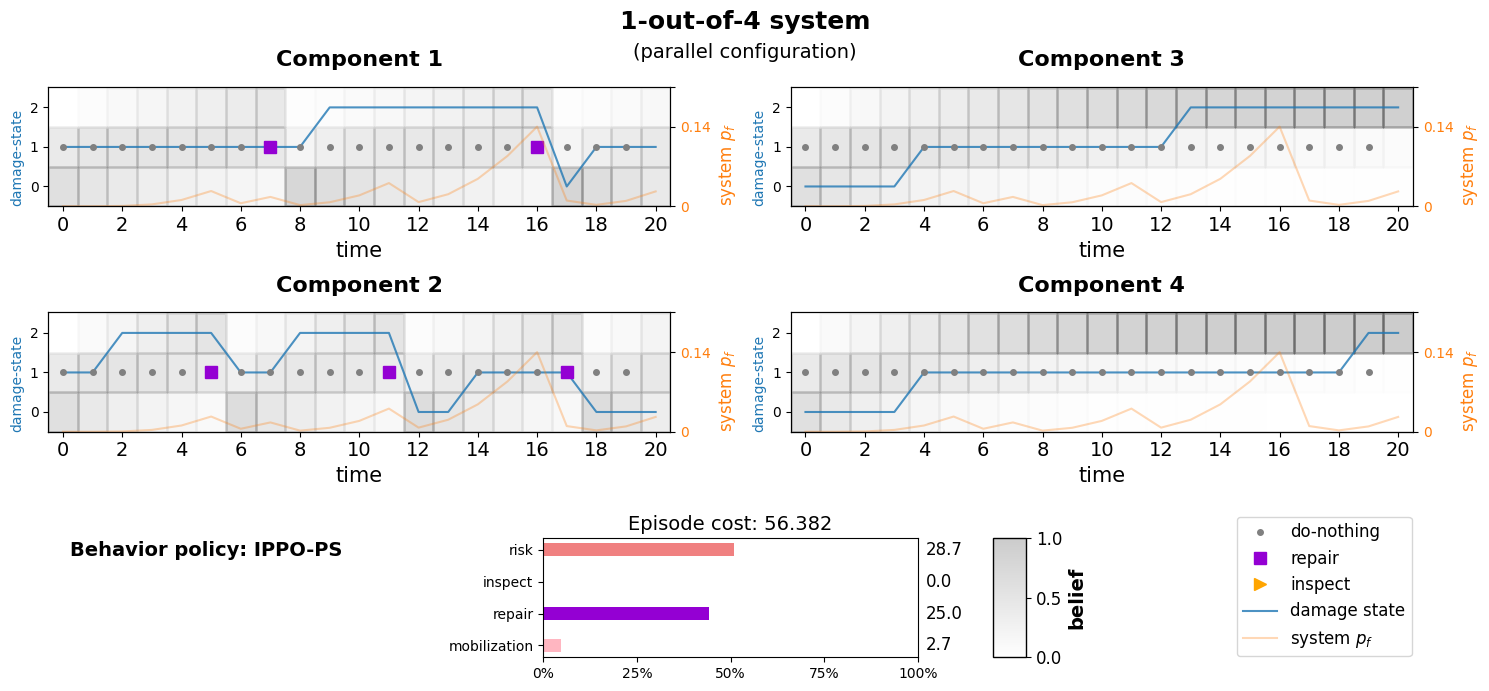

In [9]:
# save_fig_kwargs = {"fname": "./rollout.png", "dpi": 300}
save_fig_kwargs = None

plotter.plot(save_fig_kwargs=save_fig_kwargs)

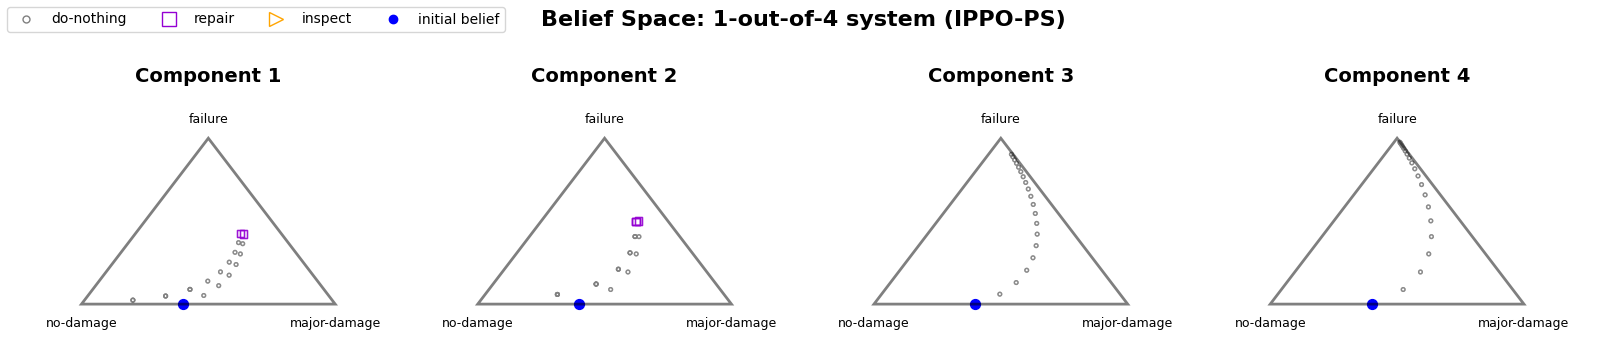

In [10]:
fig, ax = plotter.plot_belief_space(show_actions=True, num_trajectories=2)

You can also get the raw data for multiple sampled rollouts with `visualizer.get_sample_rollout_batch(...)`, which returns a dictionary of arrays containing the executed actions, belief trajectories, and other relevant data. This is useful for custom analyses of the agent's behavior across multiple trajectories.

In [11]:
data = plotter.get_sample_rollout_batch(num_trajectories=5)
for key, value in data.items():
    print(f"{key}: {value.shape}")

time: (5, 21)
true_states: (5, 21, 4)
beliefs: (5, 21, 4, 3)
actions: (5, 20, 4)
oracle_actions: (5, 20, 4)
system_pf: (5, 21)
rewards: (5, 20)
cost_mobilisation: (5, 20)
cost_risk: (5, 20)
cost_inspections: (5, 20)
cost_replacements: (5, 20)
failure_timepoints: (5, 21)
episode_cost: (5,)
